# Course 5 - Applied Social Network Analysis in Python
## Assignment 1: Creating and Manipulating Graphs with NetworkX

### Overview
This assignment introduces bipartite graphs using a real-world scenario: employees choosing movies for a company movie night. You'll create a bipartite graph, add node attributes, compute weighted projections, and calculate Pearson correlation between graph-based similarity and relationship scores.

### Learning Objectives
- Load and create NetworkX bipartite graphs from edge lists
- Add and query node attributes (type labels)
- Compute weighted bipartite projections (shared movie counts)
- Combine graph data with external relationship data
- Calculate Pearson correlation between two numeric graph properties

### Datasets
- **`assets/Employee_Movie_Choices.txt`** — Tab-delimited edge list: Employee <-> Movie (8 employees, 11 movies, 24 edges)
- **`assets/Employee_Relationships.txt`** — Tab-delimited: Employee1, Employee2, RelationshipScore (-100 to +100)

### Graph Structure
- **Bipartite graph:** Two disjoint node sets (employees and movies)
- **Employees:** Pablo, Lee, Georgia, Vincent, Andy, Frida, Joan, Claude
- **Movies:** 11 titles including The Shawshank Redemption, The Matrix, etc.
- Each employee chose exactly 3 movies

### Assignment Structure
| Question | Task |
|----------|------|
| Q1 | Load bipartite graph from file (19 nodes, 24 edges) |
| Q2 | Add `type` node attribute ('employee' or 'movie') |
| Q3 | Weighted projection onto employee nodes (shared movie count as weight) |
| Q4 | Pearson correlation between shared movie count and relationship score |

### Key Concepts
- **Bipartite projection:** Collapses one node set; edge weight = number of shared neighbors
- **Weighted projection:** `bipartite.weighted_projected_graph(G, employees)` projects onto employee nodes
- **Pearson correlation:** Measures linear relationship between two variables (scipy.stats.pearsonr)

In [1]:
import networkx as nx
import pandas as pd
import numpy as np


# This is the set of employees
employees = set(['Pablo',
                 'Lee',
                 'Georgia',
                 'Vincent',
                 'Andy',
                 'Frida',
                 'Joan',
                 'Claude'])

# This is the set of movies
movies = set(['The Shawshank Redemption',
              'Forrest Gump',
              'The Matrix',
              'Anaconda',
              'The Social Network',
              'The Godfather',
              'Monty Python and the Holy Grail',
              'Snakes on a Plane',
              'Kung Fu Panda',
              'The Dark Knight',
              'Mean Girls'])


# you can use the following function to plot graphs
# make sure to comment it out before submitting to the autograder
def plot_graph(G, weight_name=None):
    '''
    G: a networkx G
    weight_name: name of the attribute for plotting edge weights (if G is weighted)
    '''
    #%matplotlib notebook
    import matplotlib.pyplot as plt
    
    plt.figure()
    pos = nx.spring_layout(G)
    edges = G.edges()
    weights = None
    
    if weight_name:
        weights = [int(G[u][v][weight_name]) for u,v in edges]
        labels = nx.get_edge_attributes(G,weight_name)
        nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
        nx.draw_networkx(G, pos, width=weights);
    else:
        nx.draw_networkx(G, pos,);

### What This Code Does
Sets up the two node sets for the bipartite graph and defines a helper `plot_graph` function. The `employees` set (8 nodes) and `movies` set (11 nodes) form the two disjoint partitions of the bipartite graph. Edges only connect employee nodes to movie nodes — never within the same partition. `nx.bipartite_layout` places the two sets on separate vertical columns for clear visualization.

### Question 1

Using NetworkX, load in the bipartite graph from `assets/Employee_Movie_Choices.txt` and return that graph.

*This function should return a bipartite networkx graph with 19 nodes and 24 edges*

In [2]:
def answer_one():

    
    # YOUR CODE HERE
    import networkx as nx
    from networkx.algorithms import bipartite, is_bipartite

    G1 = nx.Graph()
    G1.add_nodes_from(list(employees), bipartite = 0 )
    G1.add_nodes_from(list(movies), bipartite = 1)

    display(is_bipartite(G1))

    #G1.add_edge('Andy', 'Claude')
    #G1.remove_edge('Andy', 'Claude')
    display(is_bipartite(G1))
    #G1.nodes(data = True)
    bipartite.is_bipartite_node_set(G1, movies)
    bipartite.is_bipartite_node_set(G1, employees)

    G1 = nx.read_edgelist(path = "assets/Employee_Movie_Choices.txt", delimiter = '\t')
    bipartite.sets(G1)

    pos_bipartite = nx.bipartite_layout(G1, nodes =employees, align ='vertical')
    nx.draw_networkx(G1,pos = pos_bipartite, )
    return G1
    #raise NotImplementedError() 

True

True

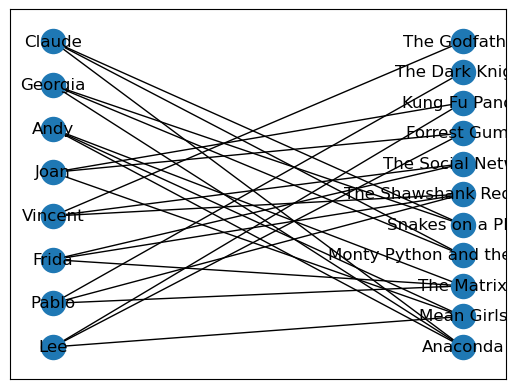

In [3]:
assert type(answer_one()) == nx.Graph , "Your return type should be a Graph object"



### Question 2

Using the graph from the previous question, add nodes attributes named `'type'` where movies have the value `'movie'` and employees have the value `'employee'` and return that graph.

*This function should return a bipartite networkx graph with node attributes `{'type': 'movie'}` or `{'type': 'employee'}`*

In [4]:
def answer_two():
    
    # YOUR CODE HERE
    G1 = answer_one()
    G1.add_nodes_from(list(employees), type ='employee')
    G1.add_nodes_from((movies), type='movie')
    G1.nodes(data =True)
    #raise NotImplementedError()
    return G1
    #raise NotImplementedError()

True

True

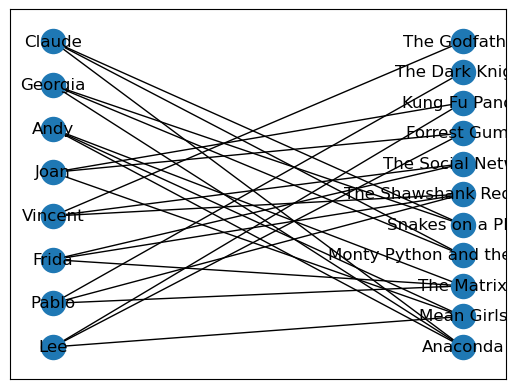

In [5]:
assert type(answer_two()) == nx.Graph , "Your return type should be a Graph object"


### Question 3

Find a weighted projection of the graph from `answer_two` which tells us how many movies different pairs of employees have in common.

*This function should return a weighted projected graph.*

In [6]:
def answer_three():
    # YOUR CODE HERE
    #0- Bipartite weighted Graph prjojection
    # 
    from networkx.algorithms import bipartite 
    G1 = answer_two() 
    P = bipartite.weighted_projected_graph(G1,employees)
    pos =nx.spring_layout(P)
    edge_weights = {(u,v,):d['weight'] for u,v,d in P.edges(data=True)}
    nx.draw_networkx(P,pos, with_labels = True)
    nx.draw_networkx_edge_labels(P,pos,edge_labels=edge_weights)
    print(list(P.edges(data=True)))
    #raise NotImplementedError()
    return P
    #raise NotImplementedError()

True

True

[('Lee', 'Joan', {'weight': 3}), ('Lee', 'Andy', {'weight': 1}), ('Pablo', 'Vincent', {'weight': 1}), ('Pablo', 'Andy', {'weight': 1}), ('Pablo', 'Frida', {'weight': 2}), ('Frida', 'Vincent', {'weight': 2}), ('Frida', 'Andy', {'weight': 1}), ('Joan', 'Andy', {'weight': 1}), ('Andy', 'Georgia', {'weight': 1}), ('Andy', 'Claude', {'weight': 1}), ('Georgia', 'Claude', {'weight': 3})]


EdgeDataView([('Lee', 'Joan', {'weight': 3}), ('Lee', 'Andy', {'weight': 1}), ('Pablo', 'Vincent', {'weight': 1}), ('Pablo', 'Andy', {'weight': 1}), ('Pablo', 'Frida', {'weight': 2}), ('Frida', 'Vincent', {'weight': 2}), ('Frida', 'Andy', {'weight': 1}), ('Joan', 'Andy', {'weight': 1}), ('Andy', 'Georgia', {'weight': 1}), ('Andy', 'Claude', {'weight': 1}), ('Georgia', 'Claude', {'weight': 3})])

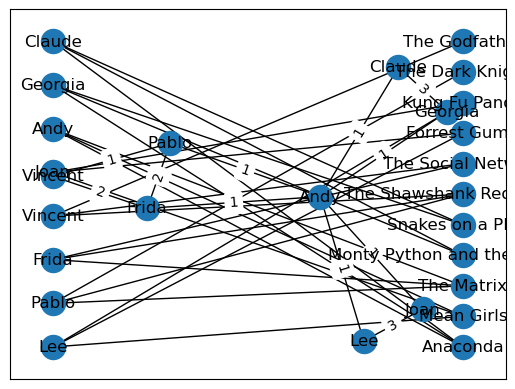

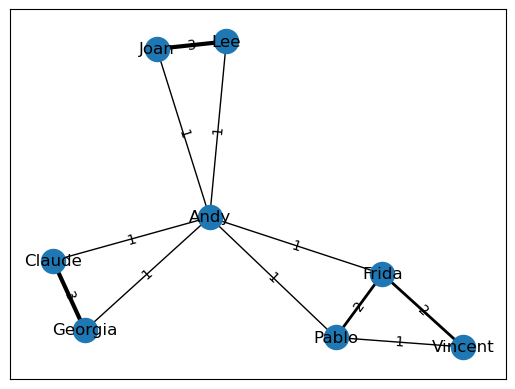

In [7]:
G = answer_three()
plot_graph(G, weight_name="weight")
G.edges(data = True)

True

True

[('Lee', 'Joan', {'weight': 3}), ('Lee', 'Andy', {'weight': 1}), ('Pablo', 'Vincent', {'weight': 1}), ('Pablo', 'Andy', {'weight': 1}), ('Pablo', 'Frida', {'weight': 2}), ('Frida', 'Vincent', {'weight': 2}), ('Frida', 'Andy', {'weight': 1}), ('Joan', 'Andy', {'weight': 1}), ('Andy', 'Georgia', {'weight': 1}), ('Andy', 'Claude', {'weight': 1}), ('Georgia', 'Claude', {'weight': 3})]


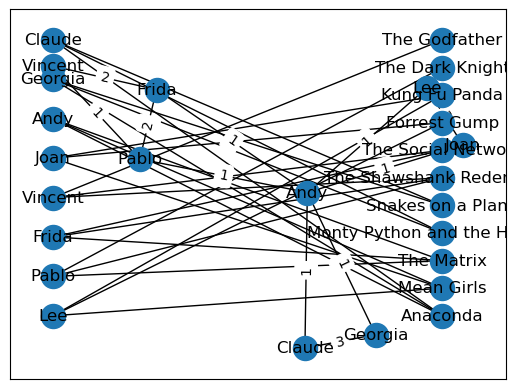

In [8]:
assert type(answer_three()) == nx.Graph , "Your return type should be a Graph object"


### Question 4

Suppose you'd like to find out if people that have a high relationship score also like the same types of movies.

Find the pearson correlation between employee relationship scores and the number of movies they have in common. If two employees have no movies in common it should be treated as a 0, not a missing value, and should be included in the correlation calculation.

*This function should return a float.*

In [9]:
def answer_four():
    
    # YOUR CODE HERE
    # YOUR CODE HERE
    P=answer_three()
    P.edges(data = True)

    edge_list_1 = P.edges(data=True)
    display(edge_list_1)
    display(len(edge_list_1))
    df = pd.read_csv("assets/Employee_Relationships.txt", delimiter='\t', header=None, names=['n1', 'n2', 'rel_score'])
    
    G5 = nx.from_pandas_edgelist(df, 'n1', 'n2', edge_attr='rel_score')
    edge_list = G5.edges(data=True)

    display(len(edge_list))
    P.add_edges_from(edge_list)
    display(P.edges(data = True))

    edge_list_final = list(P.edges(data=True))

    item = 0 
    while item < len(edge_list_final):
            dict = edge_list_final[item][2]
            item = item+1

            if 'weight' in dict.keys():
                    pass
            else:
                dict['weight']=0

            if 'rel_score' in dict.keys():
                    pass
            else:
                dict['rel_score']=0

    #display(edge_list_final)

    weights = [weight[2]['weight'] for weight in edge_list_final]
    rel_scores = [weight[2]['rel_score'] for weight in edge_list_final]
    display(weights)
    display(rel_scores)

    from scipy.stats import pearsonr

    corr,_ = pearsonr(weights, rel_scores)
    display(corr)
    
    #raise NotImplementedError()
    return corr
    raise NotImplementedError()

True

True

[('Lee', 'Joan', {'weight': 3}), ('Lee', 'Andy', {'weight': 1}), ('Pablo', 'Vincent', {'weight': 1}), ('Pablo', 'Andy', {'weight': 1}), ('Pablo', 'Frida', {'weight': 2}), ('Frida', 'Vincent', {'weight': 2}), ('Frida', 'Andy', {'weight': 1}), ('Joan', 'Andy', {'weight': 1}), ('Andy', 'Georgia', {'weight': 1}), ('Andy', 'Claude', {'weight': 1}), ('Georgia', 'Claude', {'weight': 3})]


EdgeDataView([('Lee', 'Joan', {'weight': 3}), ('Lee', 'Andy', {'weight': 1}), ('Pablo', 'Vincent', {'weight': 1}), ('Pablo', 'Andy', {'weight': 1}), ('Pablo', 'Frida', {'weight': 2}), ('Frida', 'Vincent', {'weight': 2}), ('Frida', 'Andy', {'weight': 1}), ('Joan', 'Andy', {'weight': 1}), ('Andy', 'Georgia', {'weight': 1}), ('Andy', 'Claude', {'weight': 1}), ('Georgia', 'Claude', {'weight': 3})])

11

28

EdgeDataView([('Lee', 'Joan', {'weight': 3, 'rel_score': 70}), ('Lee', 'Andy', {'weight': 1, 'rel_score': -10}), ('Lee', 'Claude', {'rel_score': 0}), ('Lee', 'Frida', {'rel_score': 0}), ('Lee', 'Georgia', {'rel_score': 10}), ('Lee', 'Pablo', {'rel_score': 0}), ('Lee', 'Vincent', {'rel_score': 0}), ('Pablo', 'Vincent', {'weight': 1, 'rel_score': -20}), ('Pablo', 'Andy', {'weight': 1, 'rel_score': -10}), ('Pablo', 'Frida', {'weight': 2, 'rel_score': 50}), ('Pablo', 'Claude', {'rel_score': 10}), ('Pablo', 'Georgia', {'rel_score': 0}), ('Pablo', 'Joan', {'rel_score': 0}), ('Frida', 'Vincent', {'weight': 2, 'rel_score': 60}), ('Frida', 'Andy', {'weight': 1, 'rel_score': 20}), ('Frida', 'Claude', {'rel_score': 0}), ('Frida', 'Georgia', {'rel_score': 0}), ('Frida', 'Joan', {'rel_score': 0}), ('Vincent', 'Andy', {'rel_score': 20}), ('Vincent', 'Claude', {'rel_score': 0}), ('Vincent', 'Georgia', {'rel_score': 0}), ('Vincent', 'Joan', {'rel_score': 10}), ('Joan', 'Andy', {'weight': 1, 'rel_score

[3,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 2,
 0,
 0,
 0,
 2,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 3]

[70,
 -10,
 0,
 0,
 10,
 0,
 0,
 -20,
 -10,
 50,
 10,
 0,
 0,
 60,
 20,
 0,
 0,
 0,
 20,
 0,
 0,
 10,
 30,
 0,
 0,
 -10,
 0,
 90]

0.7883962221733474

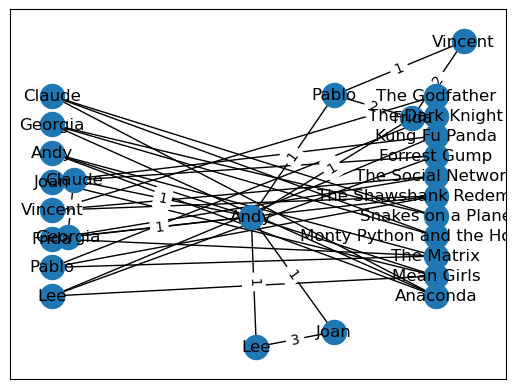

In [10]:
ans_four = answer_four()